## Exercice 1

### 1.Expliquer pourquoi la visualisation des données est importante dans l'analyse des données

La visualisation des données nous permet de transformer des données brutes en représentations visuelles pertinentes, facilitant ainsi leur interprétation et l'obtention d'informations exploitables.

### 2.  Décrire l'utilité d'un graphique linéaire en visualisation de données.

Les graphiques linéaires servent à représenter des valeurs quantitatives sur un intervalle ou une période continue.


## Exercice 2

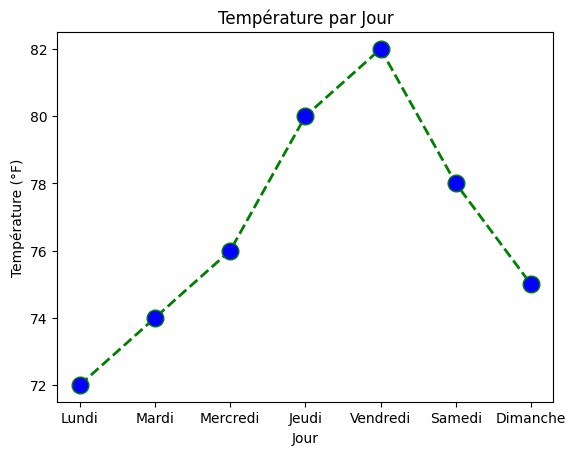

In [2]:
import matplotlib.pyplot as plt

x = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]
y = [72, 74, 76, 80, 82, 78, 75]

plt.plot(x, y, color='green', linestyle='dashed', linewidth=2, marker='o', markerfacecolor='blue', markersize=12)
plt.title('Température par Jour')
plt.xlabel('Jour')
plt.ylabel('Température (°F)')
plt.show()

## Exercice 3

In [ ]:
x = ["Janvier", "Février", "Mars", "Avril", "Mai", "Juin", "Juillet", "Août", "Septembre", "Octobre", "Novembre", "Décembre"]
y = [5000, 5500, 6200, 7000, 7500, 4000, 3500, 3000, 2500, 2000, 1500, 1000]

plt.bar(x, y)
plt.title('Ventes Mensuelles')
plt.xlabel('Mois')
plt.ylabel('Montant des ventes ($)')
plt.show()


## Exercice 4

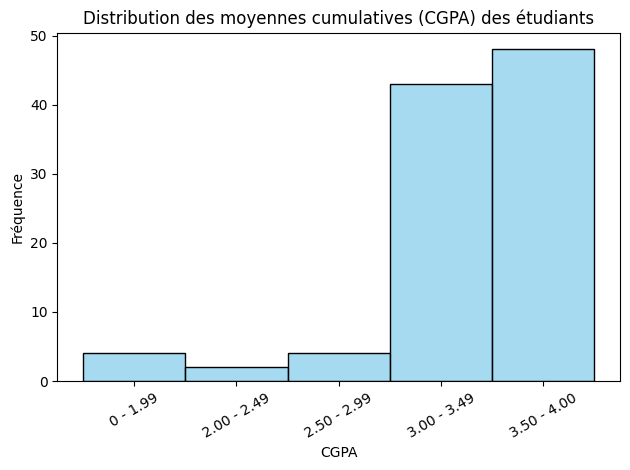

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Student Mental health.csv")

cgpa_order = [
    '0 - 1.99',
    '2.00 - 2.49',
    '2.50 - 2.99',
    '3.00 - 3.49',
    '3.50 - 4.00'
]

df['CGPA'] = pd.Categorical(df['What is your CGPA?'].astype(str).str.strip(), categories=cgpa_order, ordered=True)

gpa_codes = df['CGPA'].cat.codes
sns.histplot(x=gpa_codes, bins=len(cgpa_order), discrete=True, color='skyblue')
plt.title('Distribution des moyennes cumulatives (CGPA) des étudiants')
plt.xlabel('CGPA')
plt.ylabel('Fréquence')
plt.xticks(range(len(cgpa_order)), cgpa_order, rotation=30)
plt.tight_layout()
plt.show()

## Exercice 5

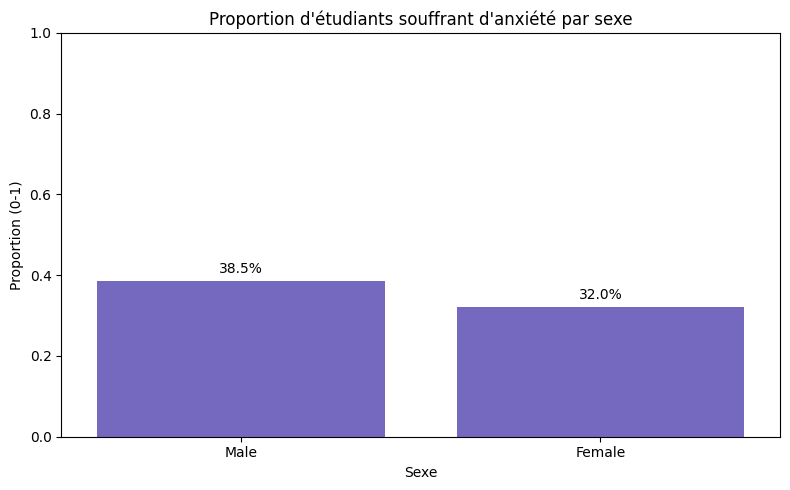

In [19]:
# Exercice 5: Comparaison des niveaux d'anxiété selon le sexe (garde ta logique)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Charger les données
if 'df' not in globals():
    df = pd.read_csv("Student Mental health.csv")

# Calculer la proportion d'anxiété ('Yes') par sexe
ct = pd.crosstab(df['Choose your gender'], df['Do you have Anxiety?'], normalize='index')
if 'Yes' in ct.columns:
    prop_anx = ct['Yes']
else:
    yes_col = [c for c in ct.columns if str(c).lower().strip() == 'yes']
    prop_anx = ct[yes_col[0]] if yes_col else pd.Series(0, index=ct.index)

prop_anx = prop_anx.sort_values(ascending=False)

# Tracer le diagramme à barres
plt.figure(figsize=(8,5))
sns.barplot(x=prop_anx.index, y=prop_anx.values, color='slateblue')
plt.title("Proportion d'étudiants souffrant d'anxiété par sexe")
plt.ylabel('Proportion (0-1)')
plt.ylim(0,1)

# Ajouter annotations en pourcentages
for i, v in enumerate(prop_anx.values):
    plt.text(i, v + 0.02, f"{v*100:.1f}%", ha='center')

plt.xlabel('Sexe')
plt.tight_layout()
plt.show()

## Exercice 6

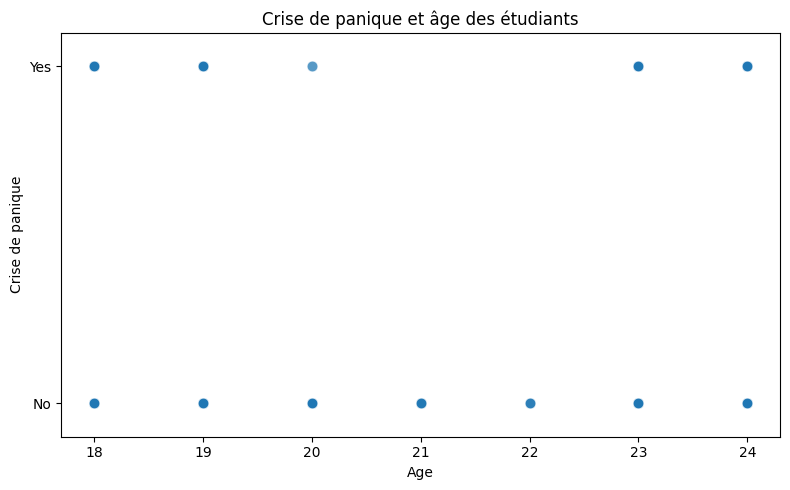

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Charger le dataframe si nécessaire
if 'df' not in globals():
    df = pd.read_csv("Student Mental health.csv")

# Convertir les réponses aux crises de panique en valeurs numériques (Yes=1, No=0)
crise_panique = df['Do you have Panic attack?'].map({'Yes':1, 'No':0, 'yes':1, 'no':0})
# Si mapping partiel, tenter une seconde tentative en normalisant les chaînes
crise_panique = crise_panique.fillna(df['Do you have Panic attack?'].astype(str).str.strip().str.lower().map({'yes':1,'no':0}))

# Convertir l'âge en numérique (coerce invalides en NaN)
age = pd.to_numeric(df['Age'], errors='coerce')

# Préparer les données à tracer en supprimant les lignes manquantes
plot_df = pd.DataFrame({'age': age, 'crise': crise_panique}).dropna()

# Tracer le nuage de points
plt.figure(figsize=(8,5))
sns.scatterplot(x=plot_df['age'], y=plot_df['crise'], s=60, alpha=0.75, edgecolor='w')
plt.yticks([0,1], ['No','Yes'])
plt.ylim(-0.1, 1.1)
plt.title("Crise de panique et âge des étudiants")
plt.xlabel('Age')
plt.ylabel('Crise de panique')
plt.tight_layout()
plt.show()